##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

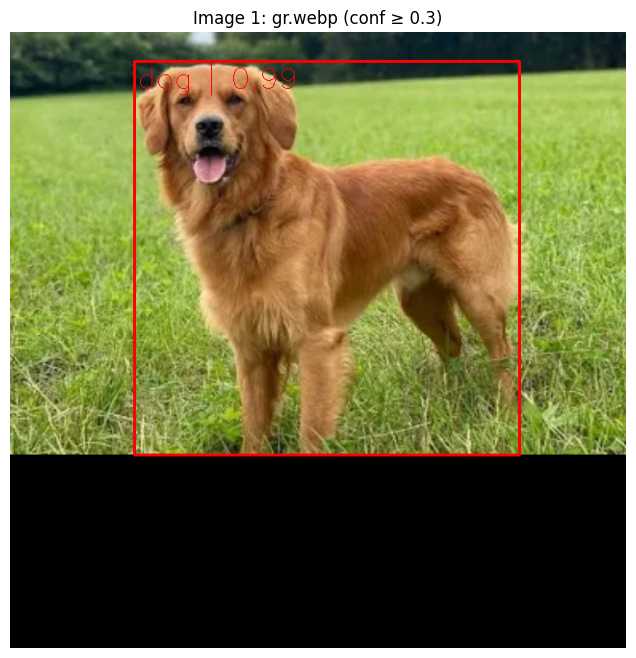

Image 1: /Users/sarahalashgar/Downloads/gr.webp
- dog           conf=0.990


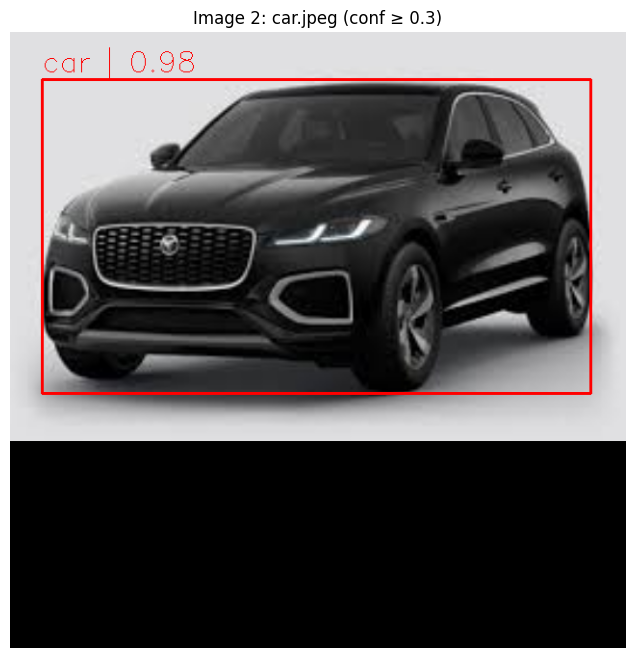

Image 2: /Users/sarahalashgar/Downloads/car.jpeg
- car           conf=0.983


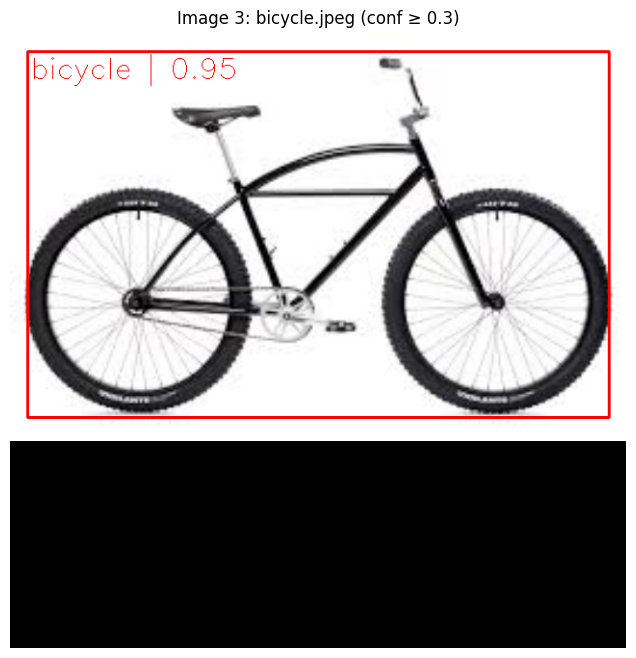

Image 3: /Users/sarahalashgar/Downloads/bicycle.jpeg
- bicycle       conf=0.949


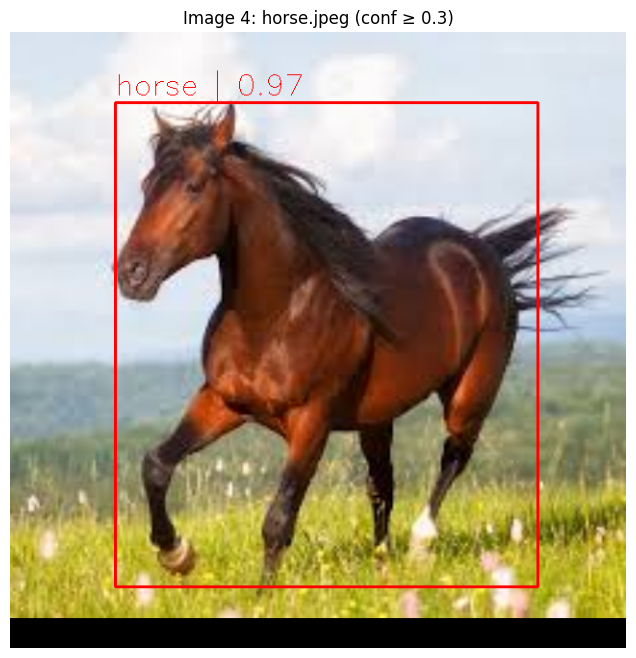

Image 4: /Users/sarahalashgar/Downloads/horse.jpeg
- horse         conf=0.971


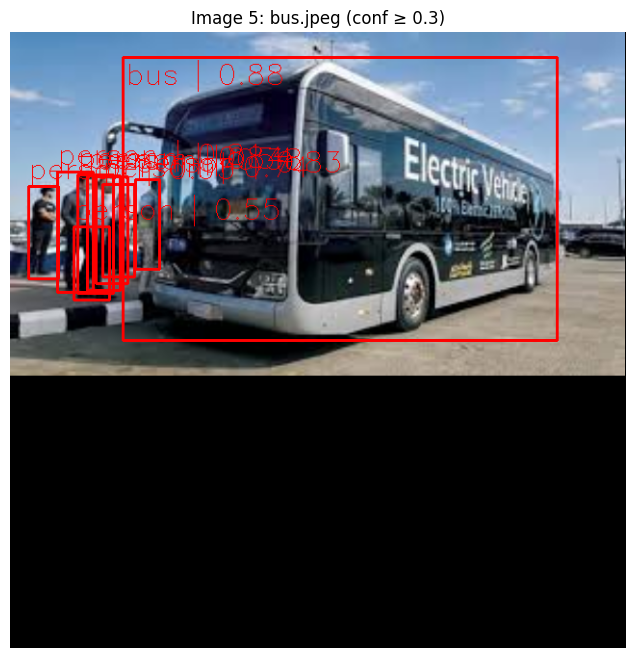

Image 5: /Users/sarahalashgar/Downloads/bus.jpeg
- person        conf=0.929
- bus           conf=0.880
- person        conf=0.838
- person        conf=0.835
- person        conf=0.812
- person        conf=0.737
- person        conf=0.547
- person        conf=0.539
- person        conf=0.378


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import keras_cv
import keras


# 0) Class names + mapping
VOC_CLASSES = [
    "aeroplane","bicycle","bird","boat","bottle",
    "bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"
]
class_mapping = {i: name for i, name in enumerate(VOC_CLASSES)}

# 1) Image paths
image_paths = [
    "/Users/sarahalashgar/Downloads/gr.webp",
    "/Users/sarahalashgar/Downloads/car.jpeg",
    "/Users/sarahalashgar/Downloads/bicycle.jpeg",
    "/Users/sarahalashgar/Downloads/horse.jpeg",
    "/Users/sarahalashgar/Downloads/bus.jpeg"
]

# 2) Load pretrained YOLOv8 (Pascal VOC)
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

# 3) Read images
images = []
for path in image_paths:
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

# 4) Resize for inference
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

resized_list = []
for img in images:
    resized_img = inference_resizing(img).numpy().astype("uint8")
    resized_list.append(resized_img)

batch = np.stack(resized_list, axis=0)  

# 5) Predict
pred = model.predict(batch, verbose=0)

# 6) Visualize + print detections
CONF_THRESH = 0.30

for i in range(batch.shape[0]):
    boxes = pred["boxes"][i]  
    classes = pred["classes"][i].astype("int32")
    confs = pred["confidence"][i]

    keep = confs >= CONF_THRESH
    boxes_f = boxes[keep][None, ...]      
    classes_f = classes[keep][None, ...]  
    confs_f = confs[keep][None, ...]     

    drawn = keras.visualization.draw_bounding_boxes(
        images=batch[i:i+1],
        bounding_boxes={
            "boxes": boxes_f,
            "labels": classes_f,
            "confidences": confs_f,
        },
        bounding_box_format="xywh",
        class_mapping=class_mapping,
        color=(255, 0, 0),
    )

    plt.figure(figsize=(8, 8))
    plt.imshow(drawn[0].astype("uint8"))
    plt.axis("off")
    plt.title(f"Image {i+1}: {image_paths[i].split('/')[-1]} (conf ≥ {CONF_THRESH})")
    plt.show()

    print("=" * 80)
    print(f"Image {i+1}: {image_paths[i]}")
    if boxes_f.shape[1] == 0:
        print("No detections above threshold.")
    else:
        for cls_id, score in zip(classes_f[0], confs_f[0]):
            name = class_mapping.get(int(cls_id), str(int(cls_id)))
            print(f"- {name:12s}  conf={float(score):.3f}")